# Setup

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
import scvi
import scrnatools as rna
import seaborn as sns
import pandas as pd
from adjustText import adjust_text
from matplotlib_venn import venn2, venn2_unweighted, venn2_circles
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import celltypist
import logging
from matplotlib.colors import Normalize, LinearSegmentedColormap
import math
import pickle
from adjustText import adjust_text
from scipy.stats import ttest_ind

In [4]:
# Set seeds
scvi.settings.seed = 0
scvi.settings.verbosity = logging.WARNING

Global seed set to 0


In [5]:
# Setup figure params
plt.rcParams["pdf.use14corefonts"] = True
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = "Helvetica"
sc.set_figure_params(dpi=80, dpi_save=300, facecolor="white", frameon=False)
sns.set_context("paper")
plt.rcParams["axes.grid"] = False
plt.rcParams['axes.unicode_minus'] = False

cmap = sns.color_palette("colorblind")
tab20_cmap = plt.get_cmap('tab20')
colors_to_exclude = [6, 7]  # 0-based index, so 6 and 7 represent the 7th and 8th colors
new_tab20 = [tab20_cmap(i) for i in range(tab20_cmap.N) if i not in colors_to_exclude]

In [6]:
warnings.resetwarnings()

# Import data

Data paths

In [7]:
rawDataPath = "/mnt/iacchus/joe/raw_data/"
processedDataPath = "/mnt/iacchus/joe/processed_data/"

In [9]:
adata = sc.read(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/combined_all_genes_TECs.h5ad")
model = scvi.model.SCVI.load(
    f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/combined_all_genes",
    adata=adata,
)

Unable to initialize backend 'cuda': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Subclustering Immature MECs

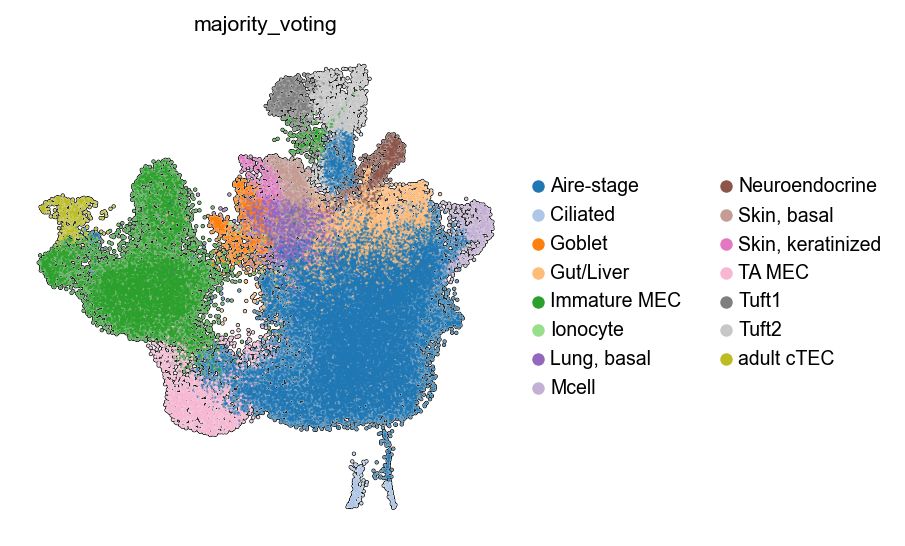

In [10]:
sc.settings.figdir = "../../analysis/subclustering/"
sc.pl.umap(
    adata,
    color="majority_voting",
    add_outline=True,
    s=5, 
    save="_before_annotation_fixes.pdf"
)

In [11]:
subset_data = adata[adata.obs.majority_voting == "Immature MEC"].copy()

In [11]:
sc.tl.leiden(
    subset_data,
    resolution=0.2,
    key_added="subclustering_leiden"
)

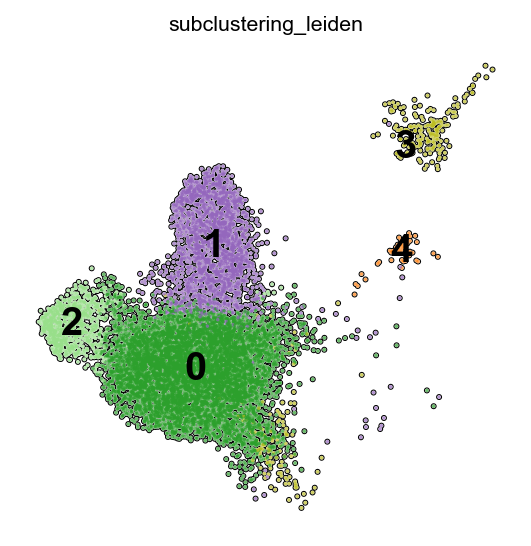

In [12]:
sc.settings.figdir = "../../analysis/subclustering/"
sc.pl.umap(
    subset_data,
    color="subclustering_leiden",
    legend_loc="on data",
    palette=["tab:green", "tab:purple", new_tab20[5], "tab:olive", "tab:orange"],
    legend_fontsize=18,
    add_outline=True,
    s=10,
    save="_immature_mec_subclustered.pdf"
)

## Add subcluster labels to full dataset

In [13]:
adata.obs["subclustered"] = adata.obs.majority_voting.astype("str")
adata.obs.loc[adata.obs.subclustered == "Immature MEC", "subclustered"] = subset_data.obs.subclustering_leiden

# Subcluster DE

In [14]:
de_dfs = {}
de_dfs_unfiltered = {}
for subcluster in ["0", "1", "2", "3", "4"]:
    de = model.differential_expression(
        adata[adata.obs.genotype == "WT"],
        groupby="subclustered",
        group1=subcluster,
    )
    de_df_filtered = de[abs(de.lfc_mean) > 1].copy()
    de_df_filtered = de_df_filtered[de_df_filtered.bayes_factor > 3]
    de_df_filtered = de_df_filtered[de_df_filtered.non_zeros_proportion1 > 0.1]
    de_dfs[subcluster] = de_df_filtered.sort_values(by="bayes_factor", ascending=False)
    de_dfs_unfiltered[subcluster] = de.sort_values(by="bayes_factor", ascending=False)

DE...: 100%|██████████| 1/1 [00:05<00:00,  5.71s/it]


## subcluster 0 - Ccl21

In [15]:
de_dfs["0"].head(15)

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
external_gene_name,,,,,,,,,,,,,,,,,,,,,
Ccl21a,0.9940,0.0060,5.109976,0.009840,0.000644,0.0,0.25,5.010840,5.218038,1.782256,...,128.074321,7.223796,0.993330,0.575045,165.858138,6.996644,True,0 vs Rest,0,Rest
Acta2,0.9916,0.0084,4.771087,0.000921,0.000082,0.0,0.25,4.353628,4.374009,1.905966,...,7.955693,0.727817,0.581229,0.167560,10.414982,0.656293,True,0 vs Rest,0,Rest
Tagln,0.9916,0.0084,4.771087,0.001633,0.000090,0.0,0.25,5.667196,6.030583,1.928669,...,12.737494,0.570834,0.790376,0.143008,16.285276,0.637769,True,0 vs Rest,0,Rest
Ctsl,0.9870,0.0130,4.329720,0.002966,0.000596,0.0,0.25,3.239188,3.408616,1.489731,...,29.300619,9.059922,0.995712,0.627309,35.526059,6.918383,True,0 vs Rest,0,Rest
Gas1,0.9854,0.0146,4.212025,0.000444,0.000079,0.0,0.25,4.046865,4.280921,2.280555,...,2.956170,0.391452,0.755598,0.093041,4.160672,0.566691,True,0 vs Rest,0,Rest
Ifi27l2a,0.9846,0.0154,4.157867,0.006039,0.000837,0.0,0.25,3.664255,3.853442,1.640674,...,54.188661,9.732890,0.997141,0.691586,70.486512,9.312288,True,0 vs Rest,0,Rest
Stmn2,0.9844,0.0156,4.144761,0.000116,0.000021,0.0,0.25,2.762619,2.676377,1.392444,...,0.840400,0.213171,0.153406,0.062697,1.035826,0.155395,True,0 vs Rest,0,Rest
Lifr,0.9844,0.0156,4.144761,0.000638,0.000146,0.0,0.25,3.038747,3.272221,1.594228,...,4.744640,0.951278,0.913768,0.283766,6.040429,1.155812,True,0 vs Rest,0,Rest
Scx,0.9830,0.0170,4.057395,0.000160,0.000022,0.0,0.25,3.707615,3.850930,1.801504,...,1.168175,0.091222,0.445927,0.047478,1.564857,0.108522,True,0 vs Rest,0,Rest


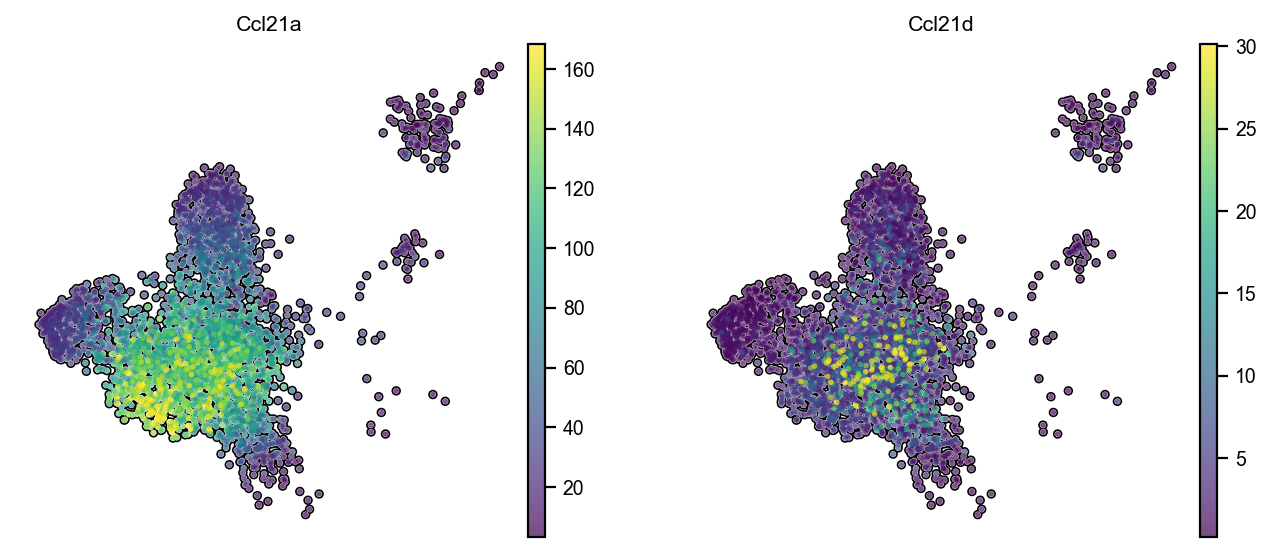

In [16]:
gene_list = ["Ccl21a", "Ccl21d"]
vmin = []
vmax = []
for gene in gene_list:
    expr = subset_data[subset_data.obs.genotype=="WT", gene].layers["scVI_normalized"]
    vmin.append(np.quantile(expr, 0.01))
    vmax.append(np.quantile(expr, 0.99))

sc.settings.figdir = "../../analysis/subclustering/"
sc.pl.umap(
    subset_data[subset_data.obs.genotype=="WT"],
    layer="scVI_normalized",
    color=gene_list,
    s=25,
    vmin=vmin,
    vmax=vmax,
    add_outline=True,
    save="_Ccl21_subcluster_DE_features.pdf"
)

In [17]:
de_dfs["0"].to_csv("../../analysis/subclustering/DE_gene_csvs/WT_Ccl21a_DE_genes.csv")

## subcluster 1 - Zeb1

In [18]:
de_dfs["1"].head(15)

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
external_gene_name,,,,,,,,,,,,,,,,,,,,,
Xylt1,0.9960,0.0040,5.517450,0.000278,0.000041,0.0,0.25,3.043601,3.027881,1.160150,...,0.919624,0.379850,0.496868,0.242432,2.540496,0.317612,True,1 vs Rest,1,Rest
BC034090,0.9932,0.0068,4.984008,0.000182,0.000021,0.0,0.25,3.499161,3.468921,1.428181,...,0.584551,0.139460,0.382046,0.099342,1.761680,0.125463,True,1 vs Rest,1,Rest
Ccdc88c,0.9914,0.0086,4.747355,0.000396,0.000061,0.0,0.25,2.823820,2.884634,1.064566,...,1.456159,0.665305,0.641962,0.373088,4.098002,0.550609,True,1 vs Rest,1,Rest
Bcr,0.9908,0.0092,4.679308,0.000105,0.000028,0.0,0.25,2.011017,2.047411,0.731292,...,0.369520,0.283912,0.289144,0.212979,1.037997,0.238084,True,1 vs Rest,1,Rest
Sh3pxd2b,0.9908,0.0092,4.679308,0.000153,0.000017,0.0,0.25,3.788647,3.838181,1.574739,...,0.562630,0.140685,0.372651,0.102246,1.540045,0.130039,True,1 vs Rest,1,Rest
Sdk2,0.9902,0.0098,4.615524,0.000103,0.000019,0.0,0.25,2.650587,2.709735,1.070682,...,0.411273,0.196732,0.307933,0.157341,1.153063,0.176948,True,1 vs Rest,1,Rest
Fto,0.9884,0.0116,4.445082,0.000144,0.000029,0.0,0.25,2.535396,2.627223,1.010901,...,0.489562,0.287724,0.345511,0.217563,1.348494,0.256671,True,1 vs Rest,1,Rest
Plxnb1,0.9882,0.0118,4.427785,0.000196,0.000040,0.0,0.25,2.579598,2.595136,1.083942,...,0.604384,0.391287,0.409186,0.268754,1.757413,0.345966,True,1 vs Rest,1,Rest
Plce1,0.9882,0.0118,4.427785,0.000234,0.000037,0.0,0.25,2.918241,2.939934,1.266752,...,0.831942,0.274291,0.486430,0.164239,2.450726,0.226843,True,1 vs Rest,1,Rest


In [19]:
de_dfs["1"].to_csv("../../analysis/subclustering/DE_gene_csvs/WT_Zeb1_DE_genes.csv")

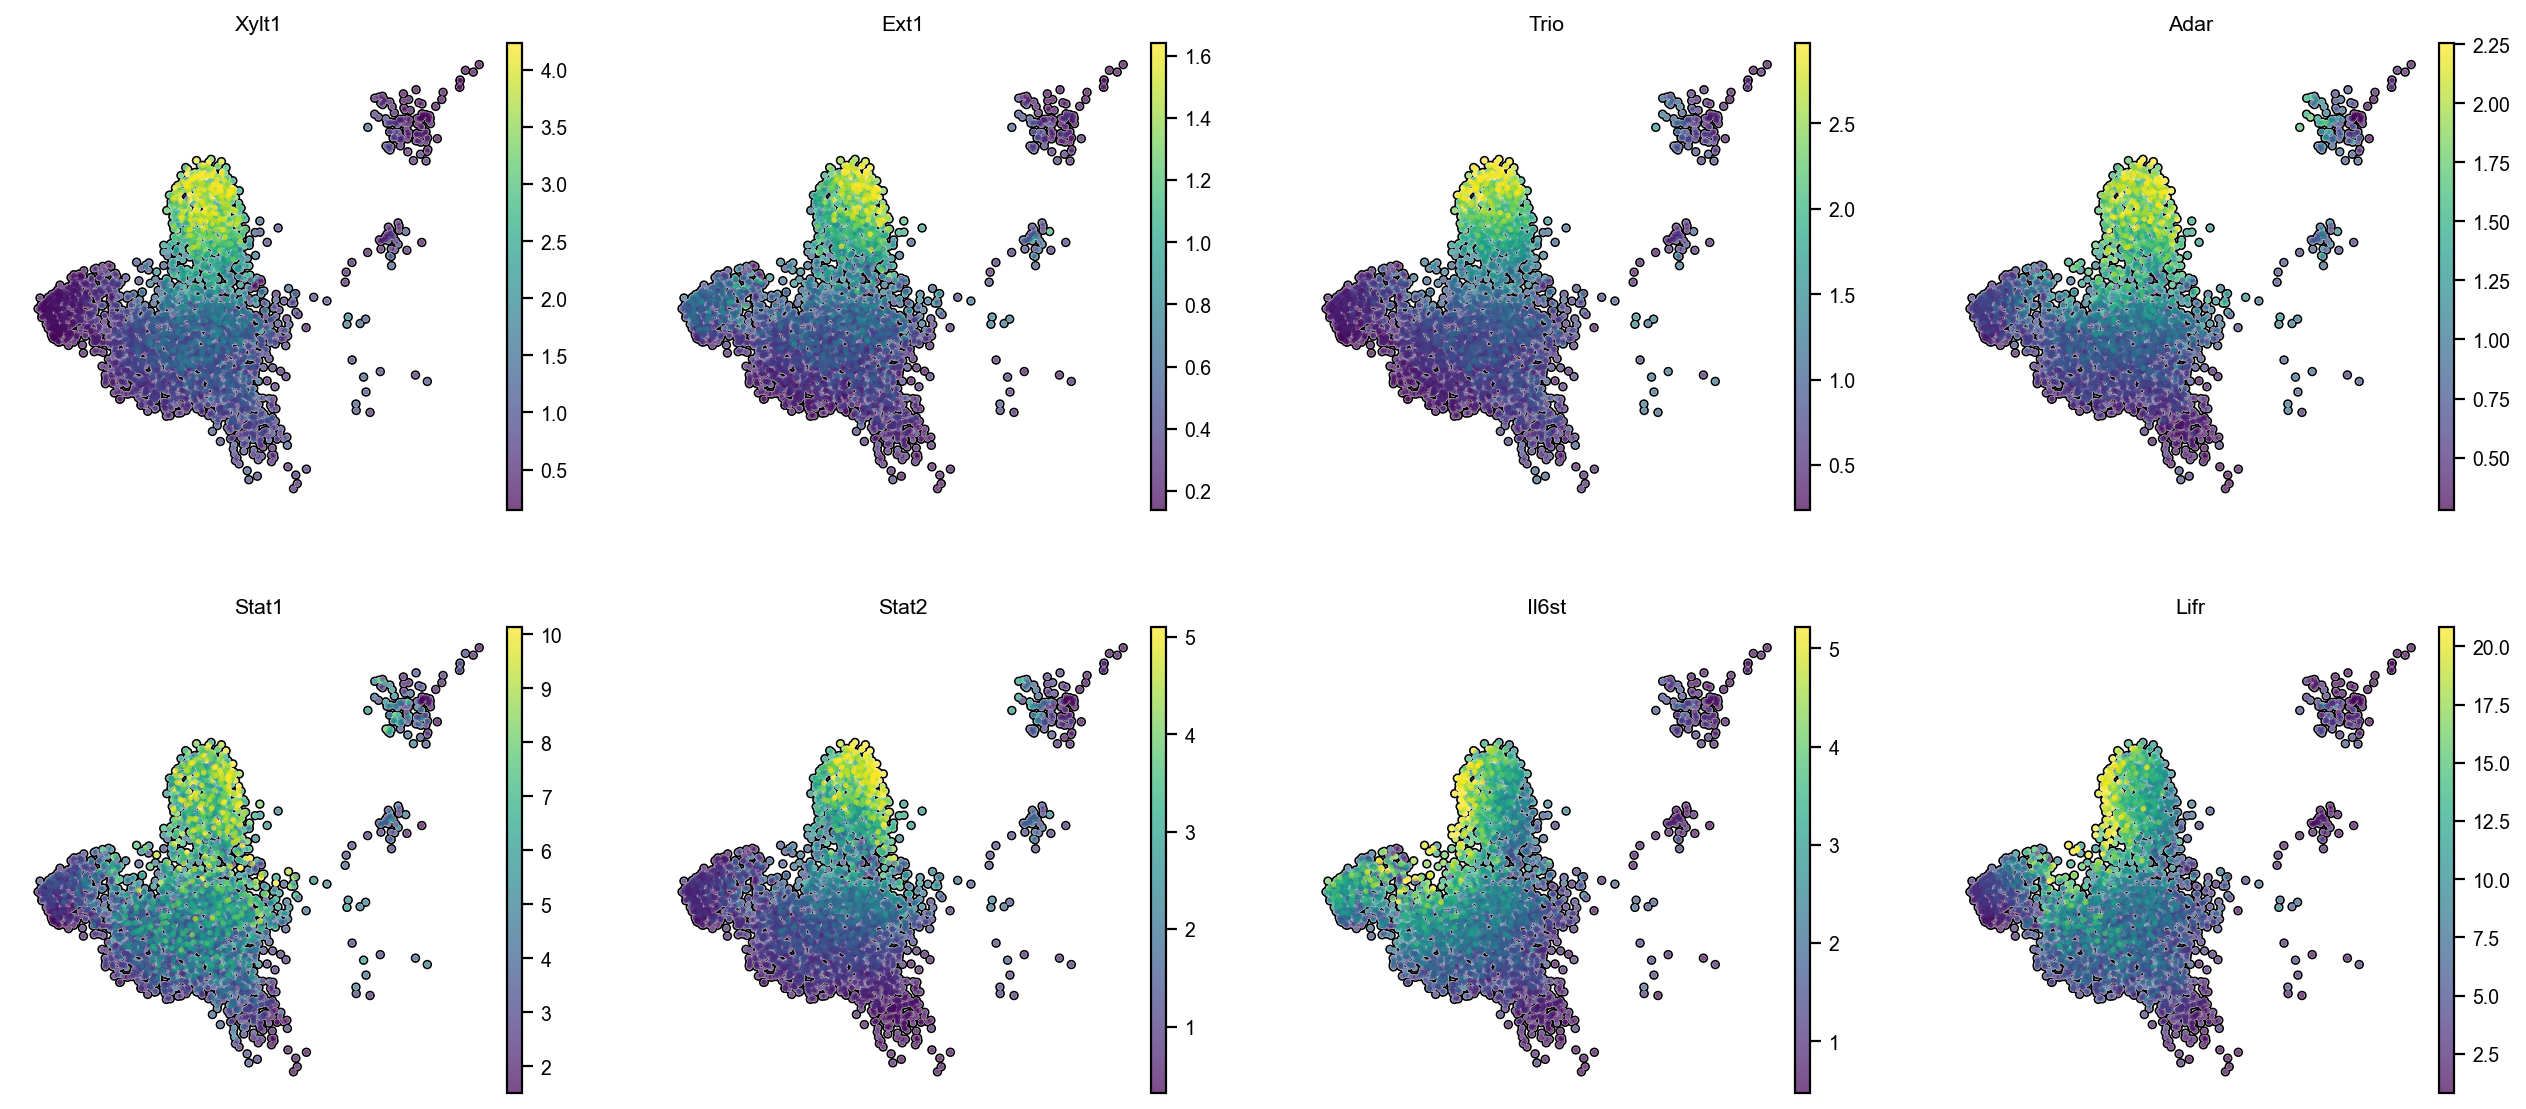

In [12]:
gene_list = ["Xylt1", "Ext1", "Trio", "Adar", "Stat1", "Stat2", "Il6st", "Lifr"]
vmin = []
vmax = []
for gene in gene_list:
    expr = subset_data[subset_data.obs.genotype=="WT", gene].layers["scVI_normalized"]
    vmin.append(np.quantile(expr, 0.01))
    vmax.append(np.quantile(expr, 0.99))

sc.settings.figdir = "../../analysis/subclustering_figures/"
sc.pl.umap(
    subset_data[subset_data.obs.genotype == "WT"],
    layer="scVI_normalized",
    color=gene_list,
    s=25,
    vmin=vmin,
    vmax=vmax,
    add_outline=True,
    save="_Zeb1_subcluster_DE_features.pdf"
)

## subcluster 2 - Bcam

In [21]:
de_dfs["2"].head(15)

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
external_gene_name,,,,,,,,,,,,,,,,,,,,,
Prelp,0.9982,0.0018,6.318161,0.000379,0.000023,0.0,0.25,4.802896,4.666819,1.941826,...,1.882488,0.049204,0.718894,0.024646,3.234967,0.046971,True,2 vs Rest,2,Rest
Dcn,0.9978,0.0022,6.117091,0.001812,0.000118,0.0,0.25,4.334209,4.331260,1.460844,...,12.253456,0.933375,0.905530,0.211800,20.299603,0.799446,True,2 vs Rest,2,Rest
Cpne8,0.9972,0.0028,5.875328,0.000407,0.000042,0.0,0.25,3.622368,3.773365,1.054961,...,2.417051,0.385655,0.822581,0.249878,3.871236,0.362138,True,2 vs Rest,2,Rest
Ackr4,0.9970,0.0030,5.806135,0.000310,0.000023,0.0,0.25,4.366493,4.380510,1.634225,...,1.822581,0.118755,0.654378,0.057449,3.084715,0.108995,True,2 vs Rest,2,Rest
Prss23,0.9966,0.0034,5.680571,0.000126,0.000008,0.0,0.25,4.867951,4.747487,2.067390,...,0.679724,0.016845,0.368664,0.009265,1.027608,0.014054,True,2 vs Rest,2,Rest
Smim1,0.9956,0.0044,5.421739,0.000102,0.000014,0.0,0.25,2.993455,3.013978,1.096398,...,0.605991,0.091715,0.373272,0.063655,0.962460,0.073061,True,2 vs Rest,2,Rest
Pmp22,0.9952,0.0048,5.334326,0.000203,0.000022,0.0,0.25,3.814848,3.799706,1.542443,...,1.078341,0.054612,0.506912,0.026553,1.704837,0.047822,True,2 vs Rest,2,Rest
Gas1,0.9952,0.0048,5.334326,0.001424,0.000081,0.0,0.25,5.738737,5.968301,2.168181,...,9.131336,0.461944,0.935484,0.138481,14.913474,0.625083,True,2 vs Rest,2,Rest
Igfbp7,0.9952,0.0048,5.334326,0.000319,0.000037,0.0,0.25,3.746579,3.718846,1.494180,...,2.002304,0.185159,0.587558,0.050002,2.953429,0.142846,True,2 vs Rest,2,Rest


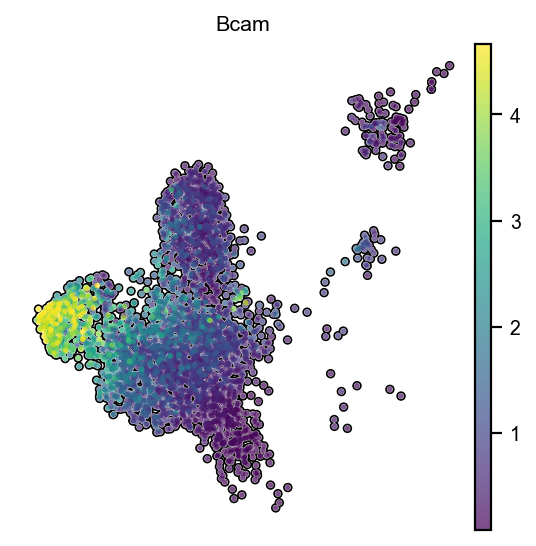

In [22]:
gene_list = ["Bcam"]
vmin = []
vmax = []
for gene in gene_list:
    expr = subset_data[subset_data.obs.genotype=="WT", gene].layers["scVI_normalized"]
    vmin.append(np.quantile(expr, 0.01))
    vmax.append(np.quantile(expr, 0.99))

sc.settings.figdir = "../../analysis/subclustering/"
sc.pl.umap(
    subset_data[subset_data.obs.genotype == "WT"],
    layer="scVI_normalized",
    color=gene_list,
    s=25,
    vmin=vmin,
    vmax=vmax,
    add_outline=True,
    save="_Bcam_subcluster_DE_features.pdf"
)

In [23]:
de_dfs["2"].to_csv("../../analysis/subclustering/DE_gene_csvs/WT_Bcam_DE_genes.csv")

## subcluster 3 - Tuft

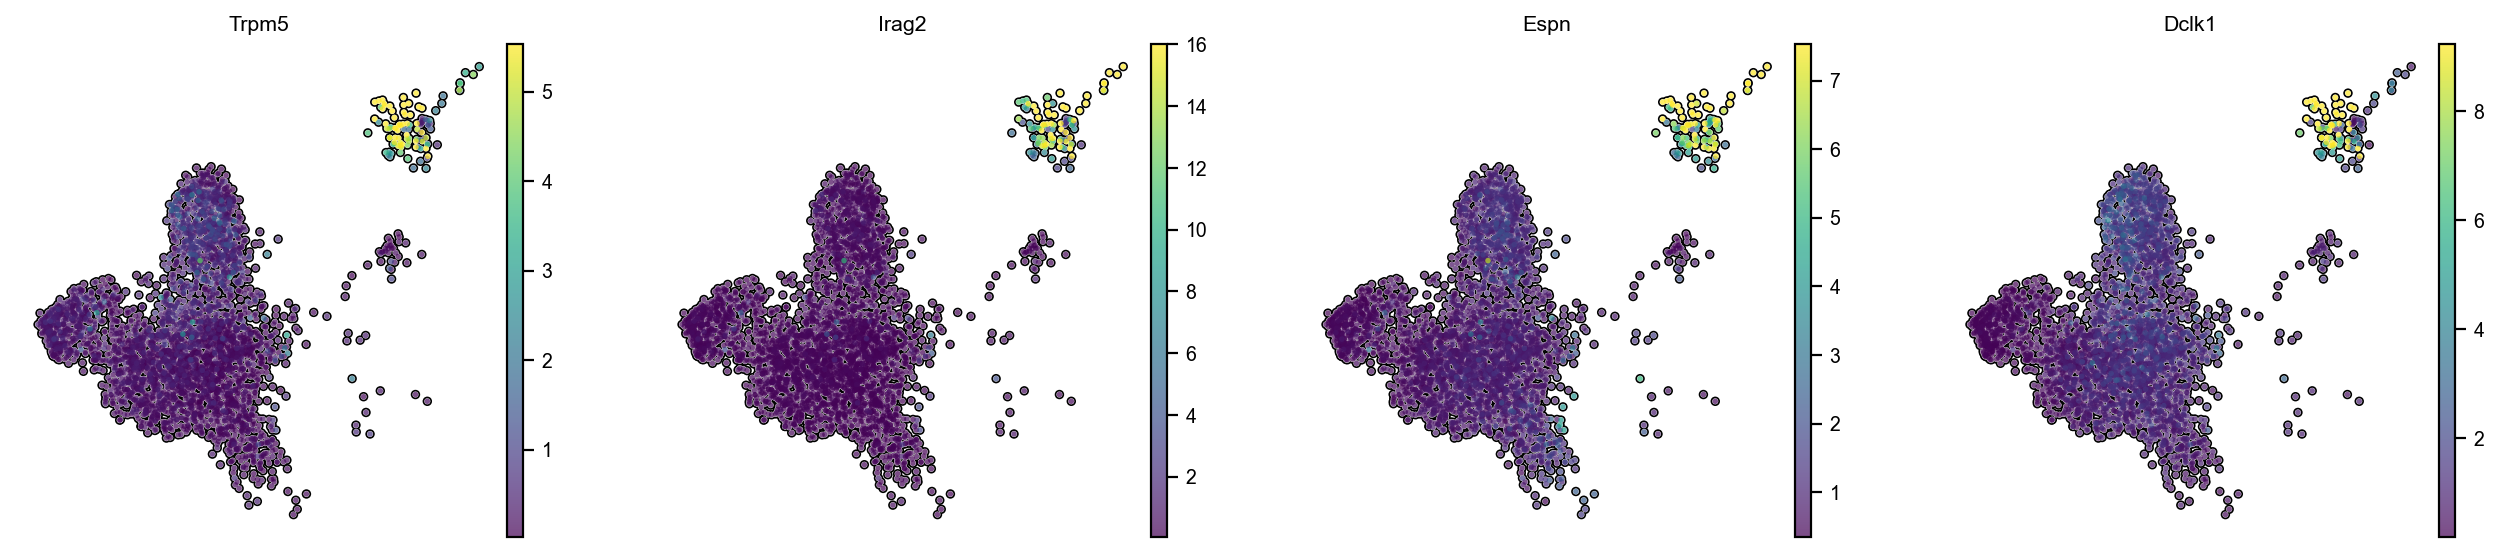

In [24]:
gene_list = ["Trpm5", "Irag2", "Espn", "Dclk1"]
vmin = []
vmax = []
for gene in gene_list:
    expr = subset_data[subset_data.obs.genotype=="WT", gene].layers["scVI_normalized"]
    vmin.append(np.quantile(expr, 0.01))
    vmax.append(np.quantile(expr, 0.99))

sc.settings.figdir = "../../analysis/subclustering/"
sc.pl.umap(
    subset_data[subset_data.obs.genotype=="WT"],
    layer="scVI_normalized",
    color=gene_list,
    s=25,
    vmin=vmin,
    vmax=vmax,
    add_outline=True,
    save="_Immature_MEC_reannotated_tuft_subcluster_DE_features.pdf"
)

## subcluster 4 - Lung, basal

In [25]:
de_dfs["4"].head(15)

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
external_gene_name,,,,,,,,,,,,,,,,,,,,,
Col17a1,0.9952,0.0048,5.334326,0.000361,0.000053,0.0,0.25,3.155973,3.033592,1.320039,...,10.064516,0.462590,0.967742,0.219667,7.803836,0.391683,True,4 vs Rest,4,Rest
Krt15,0.9950,0.0050,5.293303,0.000433,0.000035,0.0,0.25,4.499659,4.442970,1.850814,...,7.193548,0.516201,0.225806,0.056006,4.641329,0.414622,True,4 vs Rest,4,Rest
Krt6a,0.9894,0.0106,4.536244,0.000353,0.000043,0.0,0.25,4.734902,4.888573,2.305806,...,4.548387,0.350057,0.580645,0.037366,3.281701,0.265987,True,4 vs Rest,4,Rest
Cavin1,0.9890,0.0110,4.498798,0.000195,0.000041,0.0,0.25,2.440308,2.443483,0.972987,...,3.935484,0.347618,0.903226,0.224588,3.103983,0.317703,True,4 vs Rest,4,Rest
Tns4,0.9876,0.0124,4.377580,0.000103,0.000016,0.0,0.25,3.402375,3.362983,1.578952,...,1.967742,0.084313,0.483871,0.059315,1.576472,0.104598,True,4 vs Rest,4,Rest
Tnfrsf12a,0.9872,0.0128,4.345427,0.000204,0.000034,0.0,0.25,3.037237,3.015701,1.440849,...,2.354839,0.294182,0.806452,0.167625,1.877960,0.274651,True,4 vs Rest,4,Rest
Pmepa1,0.9870,0.0130,4.329720,0.000380,0.000081,0.0,0.25,2.499508,2.503593,1.037198,...,7.935484,0.816349,0.935484,0.357199,6.075693,0.726002,True,4 vs Rest,4,Rest
Ahr,0.9868,0.0132,4.314250,0.000084,0.000015,0.0,0.25,2.943042,3.035799,1.255563,...,1.741935,0.126296,0.580645,0.089234,1.253342,0.123122,True,4 vs Rest,4,Rest
Meiob,0.9868,0.0132,4.314250,0.000015,0.000004,0.0,0.25,2.369846,2.293979,1.154497,...,0.258065,0.023604,0.193548,0.018770,0.204980,0.020569,True,4 vs Rest,4,Rest


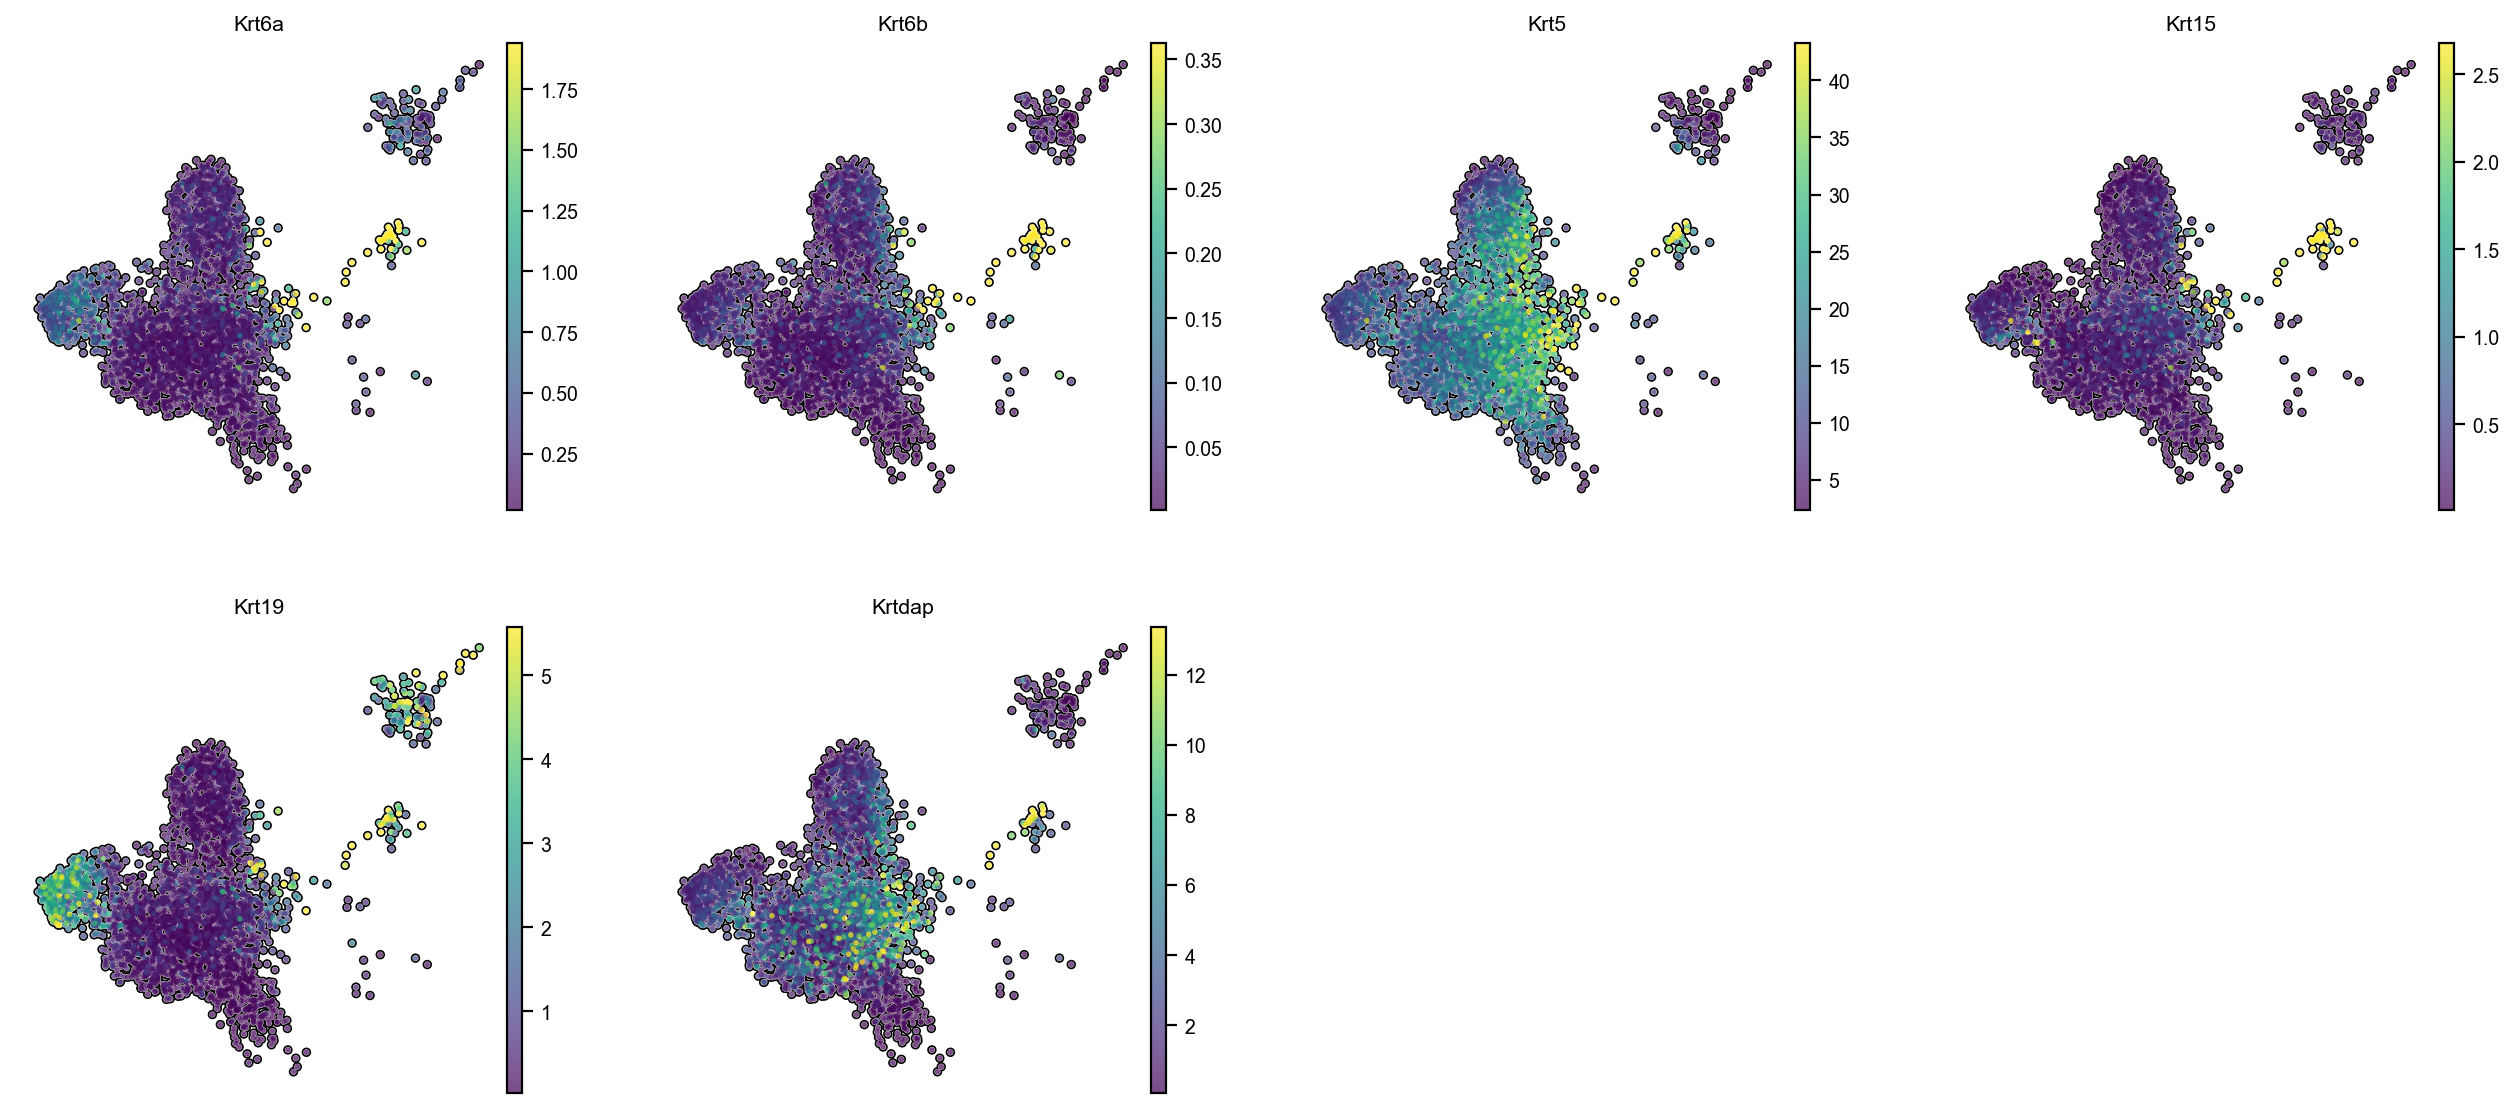

In [26]:
gene_list = ["Krt6a", "Krt6b", "Krt5", "Krt15", "Krt19", "Krtdap"]
vmin = []
vmax = []
for gene in gene_list:
    expr = subset_data[subset_data.obs.genotype=="WT", gene].layers["scVI_normalized"]
    vmin.append(np.quantile(expr, 0.01))
    vmax.append(np.quantile(expr, 0.99))

sc.settings.figdir = "../../analysis/subclustering/"
sc.pl.umap(
    subset_data[subset_data.obs.genotype=="WT"],
    layer="scVI_normalized",
    color=gene_list,
    s=25,
    vmin=vmin,
    vmax=vmax,
    add_outline=True,
    save="_Lung_basal_subcluster_DE_features.pdf"
)

## Rename subsets

In [27]:
rename_dict = {
    "0": "Immature MEC - Ccl21",
    "1": "Immature MEC - Zeb1",
    "2": "Immature MEC - Bcam",
    "3": "Tuft2",
    "4": "Lung, basal"
}
adata.obs.subclustered = adata.obs.subclustered.replace(rename_dict)
adata.obs.subclustered = adata.obs.subclustered.astype("category")

In [28]:
cats = adata.obs.subclustered.cat.categories.tolist()
cats[4], cats[5] = cats[5], cats[4]
adata.obs.subclustered = adata.obs.subclustered.cat.reorder_categories(new_categories=cats)

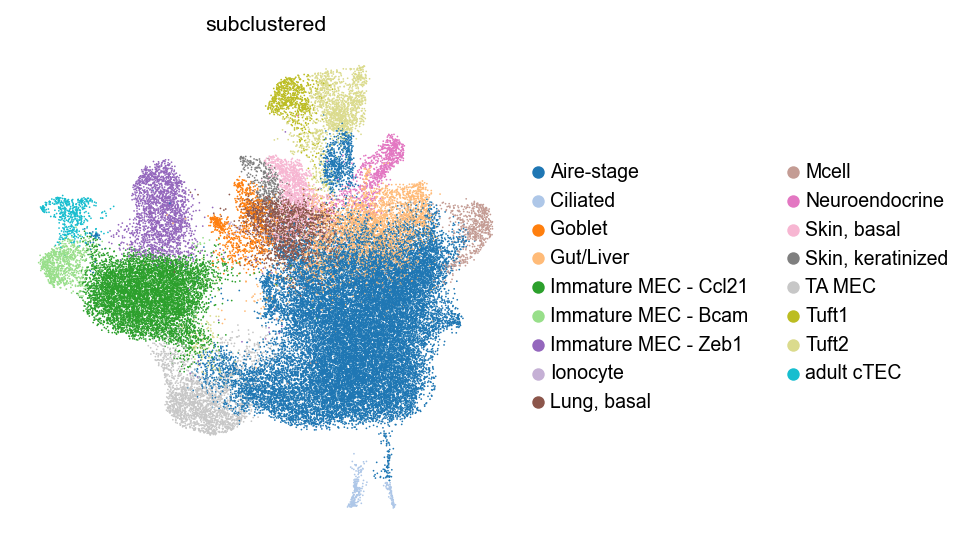

In [29]:
sc.pl.umap(
    adata,
    color="subclustered",
    palette=new_tab20
)

In [30]:
adata.write(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/combined_all_genes_TECs_final.h5ad")

# Subcluster volcanoplots

In [31]:
def volcanoplot(df, x, y, annotate_genes=None, save_path=None, annotate_genes_colors=None, *args, **kwargs):
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        linewidth=0.25,
        edgecolor="black",
        *args, **kwargs
    )
    for j,gene_list in enumerate(annotate_genes):
        if annotate_genes_colors is not None:
            color = annotate_genes_colors[j]
        else:
            color = "black"
        annotated_genes = df[df.gene.isin(gene_list)]
        texts = []
        for i, row in annotated_genes.iterrows():
            texts.append(
                plt.text(
                    row[x],
                    row[y],
                    row['gene'],
                    ha='center',
                    va='bottom',
                    fontsize=8, 
                    color=color
                )
            )
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color=color))
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

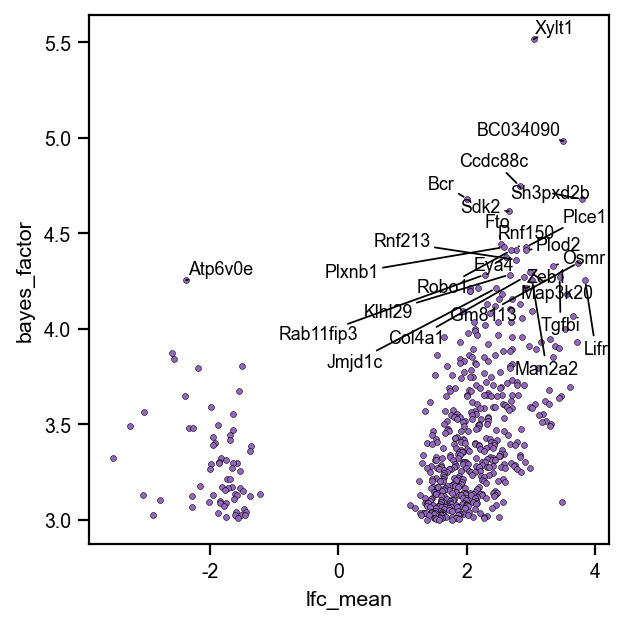

In [32]:
plot_data = de_dfs['1']
plot_data["gene"] = plot_data.index
gene_lists = [
    ["Zeb1"],
    plot_data.sort_values(by="bayes_factor", ascending=False).head(25).gene
]
volcanoplot(
    plot_data,
    x="lfc_mean",
    y="bayes_factor",
    annotate_genes=gene_lists,
    annotate_genes_colors=["black", "black"],
    s=7,
    c=[new_tab20[6]],
    save_path="../../analysis/subclustering/Zeb1_DE.pdf"
)

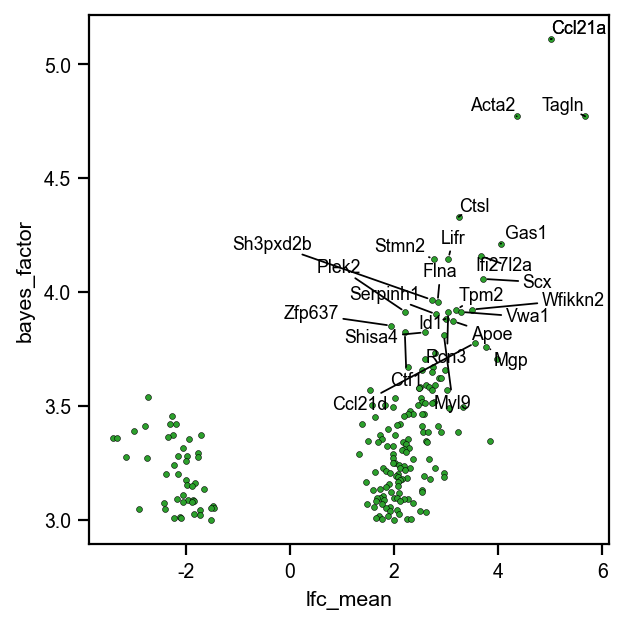

In [33]:
plot_data = de_dfs['0']
plot_data["gene"] = plot_data.index
gene_lists = [
    ["Ccl21a"],
    plot_data.sort_values(by="bayes_factor", ascending=False).head(25).gene
]
volcanoplot(
    plot_data,
    x="lfc_mean",
    y="bayes_factor",
    annotate_genes=gene_lists,
    annotate_genes_colors=["black", "black"],
    s=7,
    c=[new_tab20[4]],
    save_path="../../analysis/subclustering/Ccl21_DE.pdf"
)

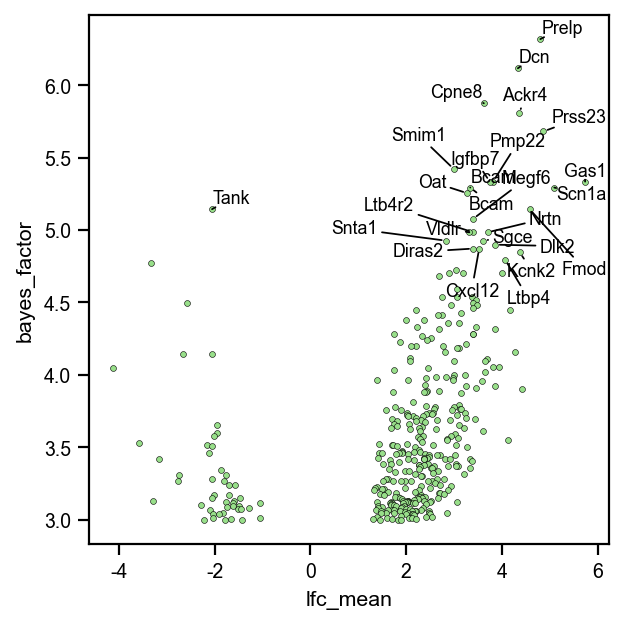

In [34]:
plot_data = de_dfs['2']
plot_data["gene"] = plot_data.index
gene_lists = [
    ["Bcam"],
    plot_data.sort_values(by="bayes_factor", ascending=False).head(25).gene
]
volcanoplot(
    plot_data,
    x="lfc_mean",
    y="bayes_factor",
    annotate_genes=gene_lists,
    annotate_genes_colors=["black", "black"],
    s=7,
    c=[new_tab20[5]],
    save_path="../../analysis/subclustering/Bcam_DE.pdf"
)

In [35]:
bcam = pd.read_csv("../../analysis/subclustering/DE_gene_csvs/WT_Bcam_DE_genes.csv")
bcam["cell_type"] = "Immature MEC - Bcam"
zeb1 = pd.read_csv("../../analysis/subclustering/DE_gene_csvs/WT_Zeb1_DE_genes.csv")
zeb1["cell_type"] = "Immature MEC - Zeb1"
ccl21a = pd.read_csv("../../analysis/subclustering/DE_gene_csvs/WT_Ccl21a_DE_genes.csv")
ccl21a["cell_type"] = "Immature MEC - Ccl21a"

In [37]:
pd.concat([bcam, zeb1, ccl21a]).to_csv("../../analysis/subclustering/DE_gene_csvs/Immature_MEC_subcluster_DE.csv")